# Aplicación web de ML con Flask

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar el dataset (URL directa de GitHub para facilidad)
url = "../data/raw/diabetes.csv"
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=names)

In [4]:
# --- EDA Rápido ---
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
print(df.describe())
print(df.isnull().sum()) # Verás que sale 0, pero hay "ceros" falsos.

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

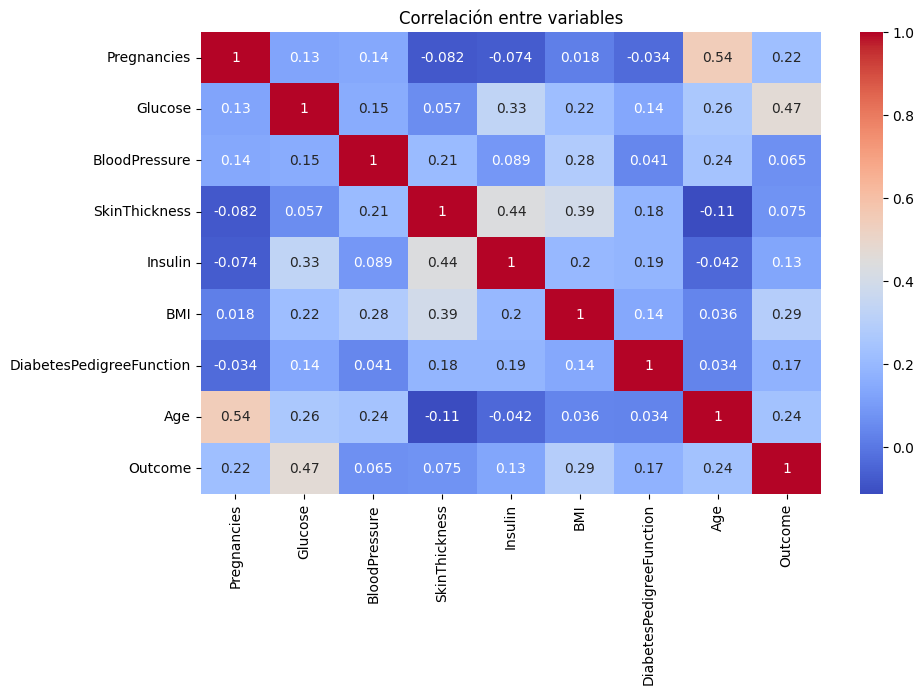

In [5]:
# Visualizar la correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlación entre variables")
plt.show()

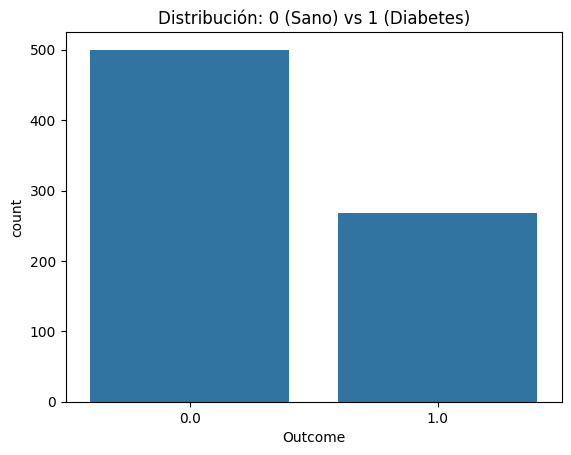

In [6]:
# Ver la distribución de la clase objetivo
sns.countplot(x='Outcome', data=df)
plt.title("Distribución: 0 (Sano) vs 1 (Diabetes)")
plt.show()

In [7]:
# Reemplazar ceros por NaN en columnas específicas
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# Imputar la mediana
df.fillna(df.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0,1.0
2,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0,0.0
3,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0,1.0
4,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
5,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
764,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0.0
765,2.0,122.0,70.0,27.0,125.0,36.8,0.340,27.0,0.0
766,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.0
767,1.0,126.0,60.0,29.0,125.0,30.1,0.349,47.0,1.0


In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Dividir datos
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optimización: Probar diferentes combinaciones de árboles y profundidad
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# El mejor modelo encontrado
best_model = grid_search.best_estimator_

# Evaluación
y_pred = best_model.predict(X_test)
print(f"Precisión final: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

# EXPORTAR EL MODELO (Crucial para Flask)
joblib.dump(best_model, '../models/diabetes_model.pkl')
print("Modelo guardado como 'diabetes_model.pkl'")

Precisión final: 0.75
              precision    recall  f1-score   support

         0.0       0.81      0.79      0.80        99
         1.0       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

Modelo guardado como 'diabetes_model.pkl'
